|Вариант|Основная таблица|Справочник / вторая таблица|Ключ|Пример группировки|
|-|-|-|-|-|
|A|orders|customers|customer_id|customer_state|

1. Прочитать выбранные таблицы из Parquet и зафиксировать число строк и исходное число partitions.
2. Сформировать цепочку минимум из трёх transformations и экспериментально показать lazy evaluation до и после Action.
3. Провести один опыт repartition()/coalesce() и сравнить physical plan двух вариантов.
4. Выполнить groupBy() по выбранному категориальному ключу, найти Exchange и зафиксировать Shuffle Read/Write во Spark UI.
5. Выполнить один и тот же JOIN как Sort Merge Join и Broadcast Hash Join. Сравнить планы, число строк результата, Stages и время.
6. Выбрать промежуточный DataFrame, используемый минимум двумя Actions, и проверить эффект persist(MEMORY_AND_DISK).
7. Провести серию минимум из четырёх значений partitions; для каждого сделать не менее трёх повторов и использовать медиану.
8. Записать итоговый DataFrame минимум с двумя разными числами partitions и сопоставить их с количеством part-файлов.
9. Приложить к отчёту не менее трёх фрагментов Spark UI: Stages/Tasks, SQL/DataFrame plan и Storage либо Join stage.
10. Сформулировать не менее пяти собственных экспериментальных выводов и минимум два ограничения измерений.


In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path(r"C:\Additional\VirtualMachines\prac4")
os.chdir(PROJECT_ROOT)
assert PROJECT_ROOT.exists(), PROJECT_ROOT
print("CWD:", Path.cwd())

CWD: C:\Additional\VirtualMachines\prac4


In [2]:
from pyspark.sql import SparkSession, functions as F
from pyspark import StorageLevel
from time import perf_counter
from statistics import median

spark = (
    SparkSession.builder
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.adaptive.enabled", "false")
    .config("spark.sql.autoBroadcastJoinThreshold", "-1")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
sc = spark.sparkContext

print("Master:", sc.master)
print("Default parallelism:", sc.defaultParallelism)
print("Shuffle partitions:", spark.conf.get("spark.sql.shuffle.partitions"))
print("AQE:", spark.conf.get("spark.sql.adaptive.enabled"))
print("Spark UI:", sc.uiWebUrl)

C:\Additional\VirtualMachines\prac4\.venv\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Master: local[*]
Default parallelism: 12
Shuffle partitions: 8
AQE: false
Spark UI: http://MSI:4040


In [3]:
import sqlite3
import pandas as pd

DB_PATH = Path("ecommerce.sqlite")
STAGING = Path("spark_input")
PARQUET = Path("spark_input_parquet")
STAGING.mkdir(exist_ok=True)
PARQUET.mkdir(exist_ok=True)

NEW_TABLES = ["orders", "customers"]

with sqlite3.connect(DB_PATH) as con:
    existing = {r[0] for r in con.execute(
        "SELECT name FROM sqlite_master WHERE type='table'")}
print("Таблицы в SQLite:", sorted(existing))

for table in NEW_TABLES:
    if table not in existing:
        print(f"⚠ {table} отсутствует в SQLite — пропускаем")
        continue

    csv_path = STAGING / f"{table}.csv"
    if not csv_path.exists():
        first, total = True, 0
        with sqlite3.connect(DB_PATH) as con:
            for chunk in pd.read_sql_query(f"SELECT * FROM {table}",
                                           con, chunksize=100_000):
                chunk.to_csv(csv_path, index=False,
                             mode="w" if first else "a",
                             header=first, encoding="utf-8")
                total += len(chunk)
                first = False
        print(f"{table}: {total} rows → CSV")
    else:
        print(f"{table}: CSV уже существует")

    df = (spark.read
          .option("header", True)
          .option("inferSchema", True)
          .csv(str(csv_path)))
    df.write.mode("overwrite").parquet(str(PARQUET / table))
    print(f"{table}: Parquet записан в {PARQUET / table}")

Таблицы в SQLite: ['customers', 'geolocation', 'leads_closed', 'leads_qualified', 'order_items', 'order_payments', 'order_reviews', 'orders', 'product_category_name_translation', 'products', 'sellers', 'sqlite_sequence', 'sqlite_stat1', 'sqlite_stat4']
orders: CSV уже существует
orders: Parquet записан в spark_input_parquet\orders
customers: CSV уже существует
customers: Parquet записан в spark_input_parquet\customers


## 1. Прочитать выбранные таблицы из Parquet и зафиксировать число строк и исходное число partitions.

In [4]:
orders = spark.read.parquet(str(PARQUET / "orders"))
customers = spark.read.parquet(str(PARQUET / "customers"))

orders_rows = orders.count()
customers_rows = customers.count()

print("\norders:")
print(f"rows = {orders_rows}")
print(f"partitions = {orders.rdd.getNumPartitions()}")
print("\norders schema:")
orders.printSchema()

print("\ncustomers:")
print(f"rows = {customers_rows}")
print(f"partitions = {customers.rdd.getNumPartitions()}")
print("\ncustomers schema:")
customers.printSchema()


orders:
rows = 99441
partitions = 5

orders schema:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)


customers:
rows = 99441
partitions = 3

customers schema:
root
 |-- customer_id: string (nullable = true)
 |-- customer_unique_id: string (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)



## 2. Сформировать цепочку минимум из трёх transformations и экспериментально показать lazy evaluation до и после Action.

In [5]:
sc.setJobGroup("SS_LAZY", "Lazy evaluation — no action")

orders_prepared = (
    orders
    .select("order_id", "customer_id", "order_status", "order_purchase_timestamp")
    .filter(F.col("order_status").isNotNull())
    .withColumn("purchase_year", F.year("order_purchase_timestamp"))
    .withColumn("is_delivered", (F.col("order_status") == "delivered").cast("int"))
)

print("Тип объекта:", type(orders_prepared).__name__)

Тип объекта: DataFrame


In [6]:
sc.setJobGroup("SS_LAZY_ACTION", "Lazy evaluation — action")

t0 = perf_counter()
n = orders_prepared.count()
t1 = perf_counter()

print("Rows:", n)
print(f"Elapsed: {t1 - t0:.3f} s")

Rows: 99441
Elapsed: 0.513 s


## 3. Провести один опыт repartition()/coalesce() и сравнить physical plan двух вариантов.

In [7]:
skewed = orders.repartition(16, "order_status")
repart4 = skewed.repartition(4)
coal4   = skewed.coalesce(4)

print("skewed:", skewed.rdd.getNumPartitions())
print("repart4:", repart4.rdd.getNumPartitions())
print("coal4:", coal4.rdd.getNumPartitions())

skewed: 16
repart4: 4
coal4: 4


In [8]:
print("========== repartition(4) ==========")
repart4.explain("formatted")

print("\n========== coalesce(4) ==========")
coal4.explain("formatted")

========== repartition(4) ==========
== Physical Plan ==
Exchange (3)
+- * ColumnarToRow (2)
   +- Scan parquet  (1)


(1) Scan parquet 
Output [8]: [order_id#60, customer_id#61, order_status#62, order_purchase_timestamp#63, order_approved_at#64, order_delivered_carrier_date#65, order_delivered_customer_date#66, order_estimated_delivery_date#67]
Batched: true
Location: InMemoryFileIndex [file:/C:/Additional/VirtualMachines/prac4/spark_input_parquet/orders]
ReadSchema: struct<order_id:string,customer_id:string,order_status:string,order_purchase_timestamp:timestamp,order_approved_at:timestamp,order_delivered_carrier_date:timestamp,order_delivered_customer_date:timestamp,order_estimated_delivery_date:timestamp>

(2) ColumnarToRow [codegen id : 1]
Input [8]: [order_id#60, customer_id#61, order_status#62, order_purchase_timestamp#63, order_approved_at#64, order_delivered_carrier_date#65, order_delivered_customer_date#66, order_estimated_delivery_date#67]

(3) Exchange
Input [8]: [order_id#6

In [9]:
def partition_profile(df):
    return (df.select(F.spark_partition_id().alias("pid"))
              .groupBy("pid").count().orderBy("pid"))

sc.setJobGroup("SS_TASK3", "repartition vs coalesce — profiles")

print("repartition(4):")
repart_profile = partition_profile(repart4).collect()
for row in repart_profile:
    print(f"pid={row['pid']} count={row['count']}")

print("\ncoalesce(4):")
coal_profile = partition_profile(coal4).collect()
for row in coal_profile:
    print(f"pid={row['pid']} count={row['count']}")

repartition(4):
pid=0 count=24860
pid=1 count=24862
pid=2 count=24859
pid=3 count=24860

coalesce(4):
pid=0 count=615
pid=1 count=1721
pid=2 count=96480
pid=3 count=625


In [10]:
def partition_stats(profile_rows, label):
    counts = [r['count'] for r in profile_rows]
    print(f"{label}: min={min(counts)}  max={max(counts)}  "
          f"mean={sum(counts)/len(counts):.0f}  total={sum(counts)}")

partition_stats(repart_profile, "repartition(4)")
partition_stats(coal_profile, "coalesce(4)")

repartition(4): min=24859  max=24862  mean=24860  total=99441
coalesce(4): min=615  max=96480  mean=24860  total=99441


- `repartition(4)` в плане → `Exchange RoundRobinPartitioning(4)`, есть полное перемешивание.
- `coalesce(4)` в плане → `Coalesce 4`, перемешивания нет.
- Оба DataFrame имеют 4 партиции и одинаковое число строк (99 441), но:
  - `repartition(4)` распределяет строки близко к равномерно;
  - `coalesce(4)` сохраняет исходный перекос, полученный после `repartition(16, "order_status")`.

## 4. Выполнить groupBy() по выбранному категориальному ключу, найти Exchange и зафиксировать Shuffle Read/Write во Spark UI.

In [11]:
sc.setJobGroup("SS_TASK4", "groupBy customer_state")

state_stats = (
    customers
    .groupBy("customer_state")
    .agg(F.count("*").alias("customers"))
    .orderBy(F.desc("customers"))
)

state_stats.show(30, truncate=False)

+--------------+---------+
|customer_state|customers|
+--------------+---------+
|SP            |41746    |
|RJ            |12852    |
|MG            |11635    |
|RS            |5466     |
|PR            |5045     |
|SC            |3637     |
|BA            |3380     |
|DF            |2140     |
|ES            |2033     |
|GO            |2020     |
|PE            |1652     |
|CE            |1336     |
|PA            |975      |
|MT            |907      |
|MA            |747      |
|MS            |715      |
|PB            |536      |
|PI            |495      |
|RN            |485      |
|AL            |413      |
|SE            |350      |
|TO            |280      |
|RO            |253      |
|AM            |148      |
|AC            |81       |
|AP            |68       |
|RR            |46       |
+--------------+---------+



In [12]:
state_stats.explain("formatted")

== Physical Plan ==
* Sort (7)
+- Exchange (6)
   +- * HashAggregate (5)
      +- Exchange (4)
         +- * HashAggregate (3)
            +- * ColumnarToRow (2)
               +- Scan parquet  (1)


(1) Scan parquet 
Output [1]: [customer_state#72]
Batched: true
Location: InMemoryFileIndex [file:/C:/Additional/VirtualMachines/prac4/spark_input_parquet/customers]
ReadSchema: struct<customer_state:string>

(2) ColumnarToRow [codegen id : 1]
Input [1]: [customer_state#72]

(3) HashAggregate [codegen id : 1]
Input [1]: [customer_state#72]
Keys [1]: [customer_state#72]
Functions [1]: [partial_count(1)]
Aggregate Attributes [1]: [count#129L]
Results [2]: [customer_state#72, count#130L]

(4) Exchange
Input [2]: [customer_state#72, count#130L]
Arguments: hashpartitioning(customer_state#72, 8), ENSURE_REQUIREMENTS, [plan_id=485]

(5) HashAggregate [codegen id : 2]
Input [2]: [customer_state#72, count#130L]
Keys [1]: [customer_state#72]
Functions [1]: [count(1)]
Aggregate Attributes [1]: [count

## 5. Выполнить один и тот же JOIN как Sort Merge Join и Broadcast Hash Join. Сравнить планы, число строк результата, Stages и время.

In [13]:
sc.setJobGroup("SS_SMJ", "Sort Merge Join: orders x customers")

smj = (
    orders.hint("merge")
          .join(customers.hint("merge"), on="customer_id", how="inner")
)

smj.explain("formatted")
print("Строк в результате:", smj.count())

== Physical Plan ==
* Project (12)
+- * SortMergeJoin Inner (11)
   :- * Sort (5)
   :  +- Exchange (4)
   :     +- * Filter (3)
   :        +- * ColumnarToRow (2)
   :           +- Scan parquet  (1)
   +- * Sort (10)
      +- Exchange (9)
         +- * Filter (8)
            +- * ColumnarToRow (7)
               +- Scan parquet  (6)


(1) Scan parquet 
Output [8]: [order_id#60, customer_id#61, order_status#62, order_purchase_timestamp#63, order_approved_at#64, order_delivered_carrier_date#65, order_delivered_customer_date#66, order_estimated_delivery_date#67]
Batched: true
Location: InMemoryFileIndex [file:/C:/Additional/VirtualMachines/prac4/spark_input_parquet/orders]
PushedFilters: [IsNotNull(customer_id)]
ReadSchema: struct<order_id:string,customer_id:string,order_status:string,order_purchase_timestamp:timestamp,order_approved_at:timestamp,order_delivered_carrier_date:timestamp,order_delivered_customer_date:timestamp,order_estimated_delivery_date:timestamp>

(2) ColumnarToRow [cod

In [14]:
def time_action(df, repeats=3):
    times = []
    for _ in range(repeats):
        t0 = perf_counter()
        df.count()
        times.append(perf_counter() - t0)
    return times, median(times)

_ = smj.count()

times_smj, med_smj = time_action(smj)
print("SMJ:", [f"{t:.3f}" for t in times_smj], f"median={med_smj:.3f} s")

SMJ: ['0.665', '0.956', '0.820'] median=0.820 s


In [15]:
sc.setJobGroup("SS_BHJ", "Broadcast Hash Join: orders x customers")

bhj = orders.join(F.broadcast(customers), on="customer_id", how="inner")

bhj.explain("formatted")
print("Строк в результате:", bhj.count())

== Physical Plan ==
* Project (9)
+- * BroadcastHashJoin Inner BuildRight (8)
   :- * Filter (3)
   :  +- * ColumnarToRow (2)
   :     +- Scan parquet  (1)
   +- BroadcastExchange (7)
      +- * Filter (6)
         +- * ColumnarToRow (5)
            +- Scan parquet  (4)


(1) Scan parquet 
Output [8]: [order_id#60, customer_id#61, order_status#62, order_purchase_timestamp#63, order_approved_at#64, order_delivered_carrier_date#65, order_delivered_customer_date#66, order_estimated_delivery_date#67]
Batched: true
Location: InMemoryFileIndex [file:/C:/Additional/VirtualMachines/prac4/spark_input_parquet/orders]
PushedFilters: [IsNotNull(customer_id)]
ReadSchema: struct<order_id:string,customer_id:string,order_status:string,order_purchase_timestamp:timestamp,order_approved_at:timestamp,order_delivered_carrier_date:timestamp,order_delivered_customer_date:timestamp,order_estimated_delivery_date:timestamp>

(2) ColumnarToRow [codegen id : 2]
Input [8]: [order_id#60, customer_id#61, order_statu

In [16]:
_ = bhj.count()

times_bhj, med_bhj = time_action(bhj)
print("BHJ:", [f"{t:.3f}" for t in times_bhj], f"median={med_bhj:.3f} s")

print(f"\nОтношение медиан: BHJ / SMJ = {med_bhj / med_smj:.2f}")

BHJ: ['0.361', '0.329', '0.487'] median=0.361 s

Отношение медиан: BHJ / SMJ = 0.44


## 6. Выбрать промежуточный DataFrame, используемый минимум двумя Actions, и проверить эффект persist(MEMORY_AND_DISK).

In [17]:
spark.catalog.clearCache()

customers_small = customers.select("customer_id", "customer_state")

joined = (
    orders
    .join(F.broadcast(customers_small), on="customer_id", how="left")
    .select("order_id", "customer_id", "customer_state",
            "order_status", "order_purchase_timestamp")
    .withColumn("purchase_year", F.year("order_purchase_timestamp"))
    .withColumn("is_delivered", (F.col("order_status") == "delivered").cast("int"))
)


def action_state(df):
    return (
        df.groupBy("customer_state")
          .agg(F.count("*").alias("n"),
               F.sum("is_delivered").alias("delivered"))
          .agg(F.sum("n").alias("c1"),
               F.sum("delivered").alias("c2"))
          .first()
    )


def action_year(df):
    return (
        df.groupBy("purchase_year")
          .agg(F.count("*").alias("n"))
          .agg(F.sum("n").alias("c1"))
          .first()[0]
    )

In [18]:
sc.setJobGroup("SS_NOCACHE", "Два действия без persist")

t0 = perf_counter(); r1 = action_state(joined); t1 = perf_counter()
r2 = action_year(joined);  t2 = perf_counter()

nocache_a1 = t1 - t0
nocache_a2 = t2 - t1

print(f"Action 1 (state): {nocache_a1:.3f} s, checksum = {r1}")
print(f"Action 2 (year): {nocache_a2:.3f} s, checksum = {r2}")
print("is_cached:", joined.is_cached)

Action 1 (state): 1.253 s, checksum = Row(c1=99441, c2=96478)
Action 2 (year): 0.687 s, checksum = 99441
is_cached: False


In [19]:
sc.setJobGroup("SS_CACHE", "persist MEMORY_AND_DISK")

cached = joined.persist(StorageLevel.MEMORY_AND_DISK)
print("После persist:", cached.is_cached)

t0 = perf_counter(); rows_c = cached.count(); mt1 = perf_counter()
_ = action_state(cached); mt2 = perf_counter()
_ = action_year(cached); mt3 = perf_counter()

mat_time = mt1 - t0
cache_a1 = mt2 - mt1
cache_a2 = mt3 - mt2

print("Rows:", rows_c)
print(f"Materialization: {mat_time:.3f} s")
print(f"Cached action 1: {cache_a1:.3f} s")
print(f"Cached action 2: {cache_a2:.3f} s")

cached.unpersist(blocking=True)
print("После unpersist:", cached.is_cached)

После persist: True
Rows: 99441
Materialization: 0.734 s
Cached action 1: 0.489 s
Cached action 2: 0.485 s
После unpersist: False


In [20]:
print(f"| {'Вариант':<15} | {'Подготовка, с':>13} | {'Action 1, с':>12} | {'Action 2, с':>12} |")
print(f"|{'-' * 17}|{'-' * 15}|{'-' * 14}|{'-' * 14}|")
print(f"| {'без persist':<15} | {'—':>13} | {nocache_a1:>12.3f} | {nocache_a2:>12.3f} |")
print(f"| {'MEMORY_AND_DISK':<15} | {mat_time:>13.3f} | {cache_a1:>12.3f} | {cache_a2:>12.3f} |")

| Вариант         | Подготовка, с |  Action 1, с |  Action 2, с |
|-----------------|---------------|--------------|--------------|
| без persist     |             — |        1.253 |        0.687 |
| MEMORY_AND_DISK |         0.734 |        0.489 |        0.485 |


## 7. Провести серию минимум из четырёх значений partitions; для каждого сделать не менее трёх повторов и использовать медиану.

In [21]:
N = 5_000_000
P_VALUES = [1, 2, 4, 8, 16, 32]
spark.conf.set("spark.sql.shuffle.partitions", "8")


def run_benchmark(p, repeats=3):
    times = []
    checksum = None
    for _ in range(repeats):
        df = (spark.range(0, N, 1, numPartitions=p)
              .withColumn("key", (F.col("id") % 1000).cast("int"))
              .withColumn("value", F.sqrt(F.col("id") + 1.0)))
        t0 = perf_counter()
        checksum = (df.groupBy("key")
                      .agg(F.sum("value").alias("s"))
                      .agg(F.sum("s").alias("checksum"))
                      .first()[0])
        times.append(perf_counter() - t0)
    return times, median(times), checksum


_ = run_benchmark(4, repeats=1)

T1 = None
results = []
for p in P_VALUES:
    sc.setJobGroup(f"SS_BENCH_p{p}", f"Benchmark partitions={p}")
    times, med, checksum = run_benchmark(p, repeats=3)
    if p == 1:
        T1 = med
    S = T1 / med if med > 0 else float("nan")
    results.append((p, times, med, S))
    print(f"p={p:2d}  times={[f'{t:.3f}' for t in times]}  "
          f"med={med:.3f}  S={S:.2f}  checksum={checksum}")

p= 1  times=['0.318', '0.179', '0.161']  med=0.179  S=1.00  checksum=7453561042.825421
p= 2  times=['0.456', '0.362', '0.353']  med=0.362  S=0.49  checksum=7453561042.82542
p= 4  times=['0.526', '0.575', '0.734']  med=0.575  S=0.31  checksum=7453561042.825421
p= 8  times=['0.489', '0.664', '0.722']  med=0.664  S=0.27  checksum=7453561042.825422
p=16  times=['1.325', '0.883', '0.993']  med=0.993  S=0.18  checksum=7453561042.82542
p=32  times=['1.372', '1.672', '1.438']  med=1.438  S=0.12  checksum=7453561042.825421


## 8. Записать итоговый DataFrame минимум с двумя разными числами partitions и сопоставить их с количеством part-файлов.

In [22]:
OUT2 = Path("self_small_files")
OUT2.mkdir(exist_ok=True)


def write_and_measure(df, p):
    path = OUT2 / f"p_{p}"
    (df.repartition(p)
       .write.mode("overwrite")
       .parquet(str(path)))

    files = list(path.glob("part-*.parquet"))
    sizes = [f.stat().st_size for f in files]
    total_mib = sum(sizes) / 1024 ** 2
    avg_kib = (sum(sizes) / len(sizes) / 1024) if sizes else 0
    return len(files), round(total_mib, 3), round(avg_kib, 1)


sc.setJobGroup("SS_TASK8", "Write with different partitions")

write_results = []
for p in [1, 4]:
    n_files, total_mib, avg_kib = write_and_measure(state_stats, p)
    write_results.append((p, n_files, total_mib, avg_kib))
    print(f"p={p}: files={n_files}  total={total_mib} MiB  avg={avg_kib} KiB")

p=1: files=1  total=0.001 MiB  avg=1.0 KiB
p=4: files=4  total=0.003 MiB  avg=0.8 KiB


## 9. Приложить к отчёту не менее трёх фрагментов Spark UI: Stages/Tasks, SQL/DataFrame plan и Storage либо Join stage.

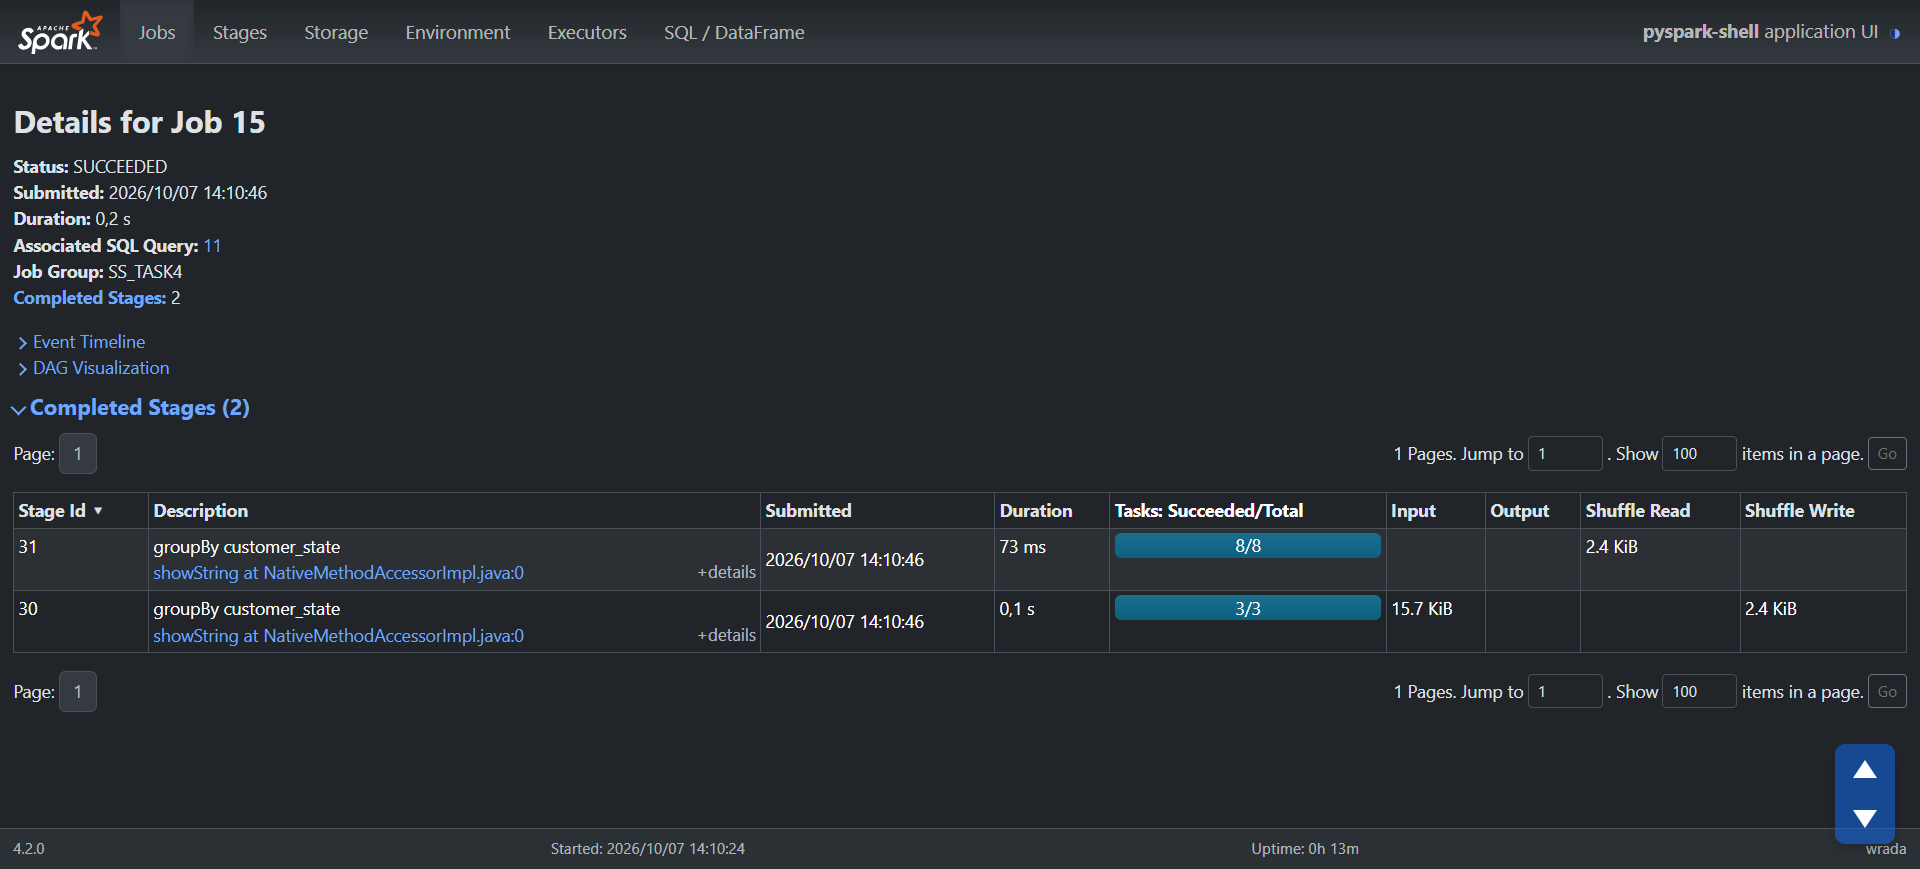

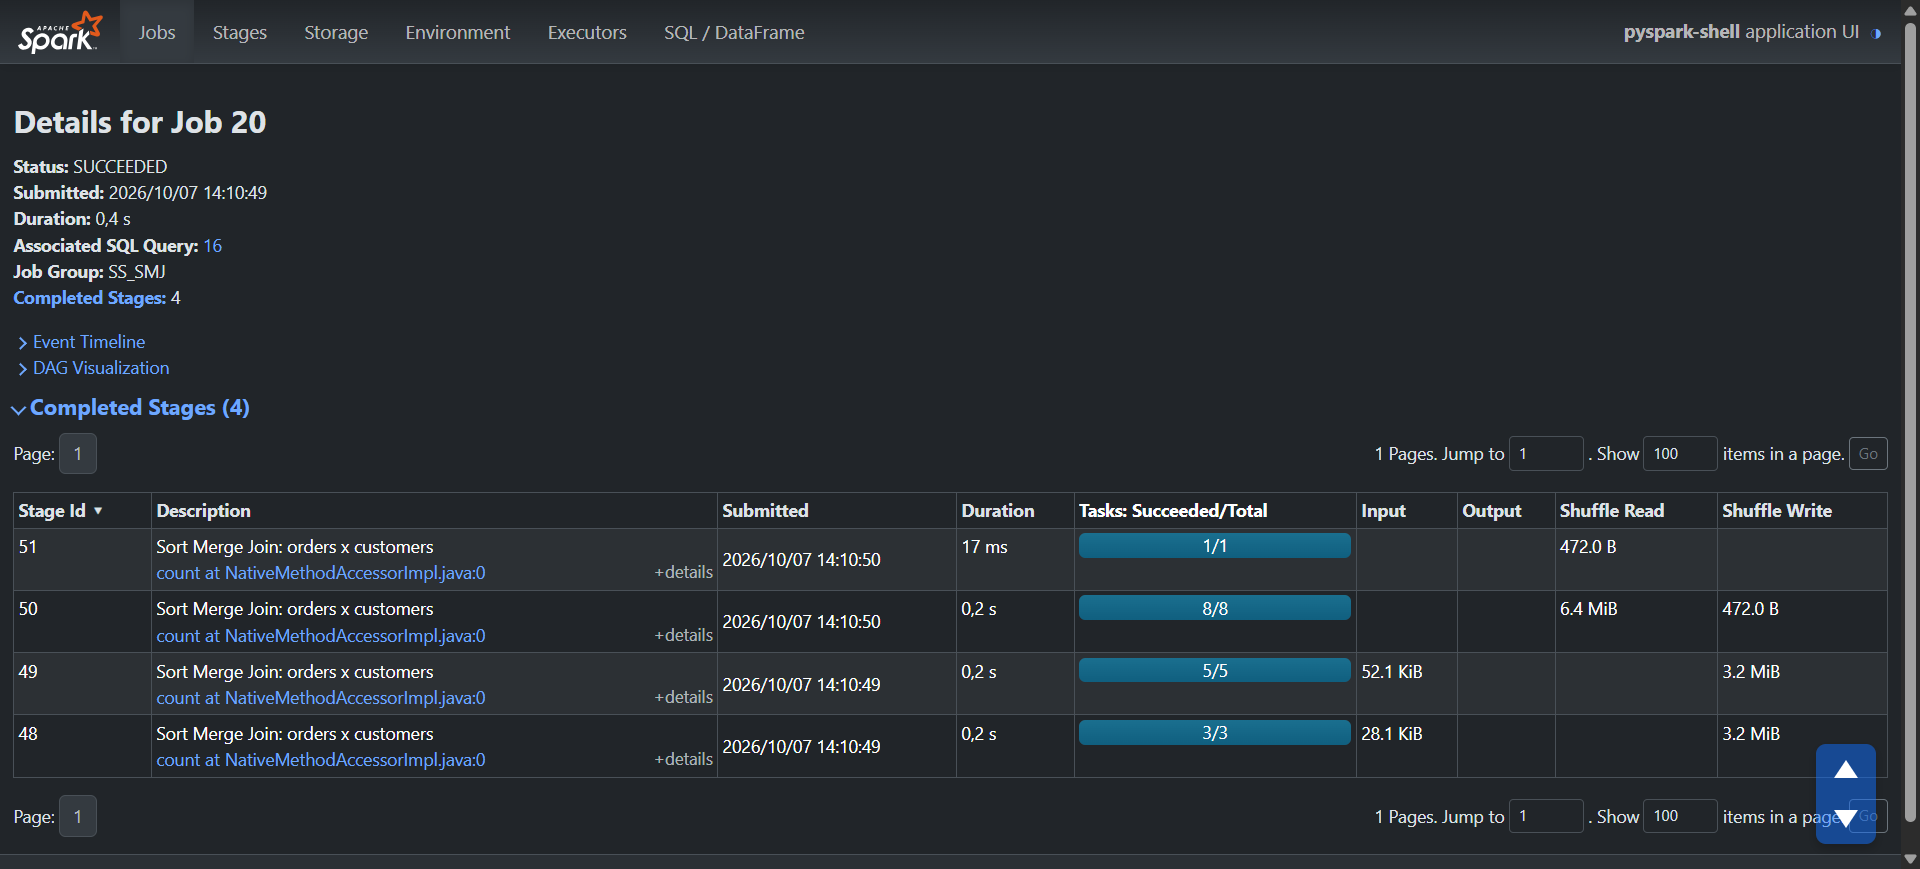

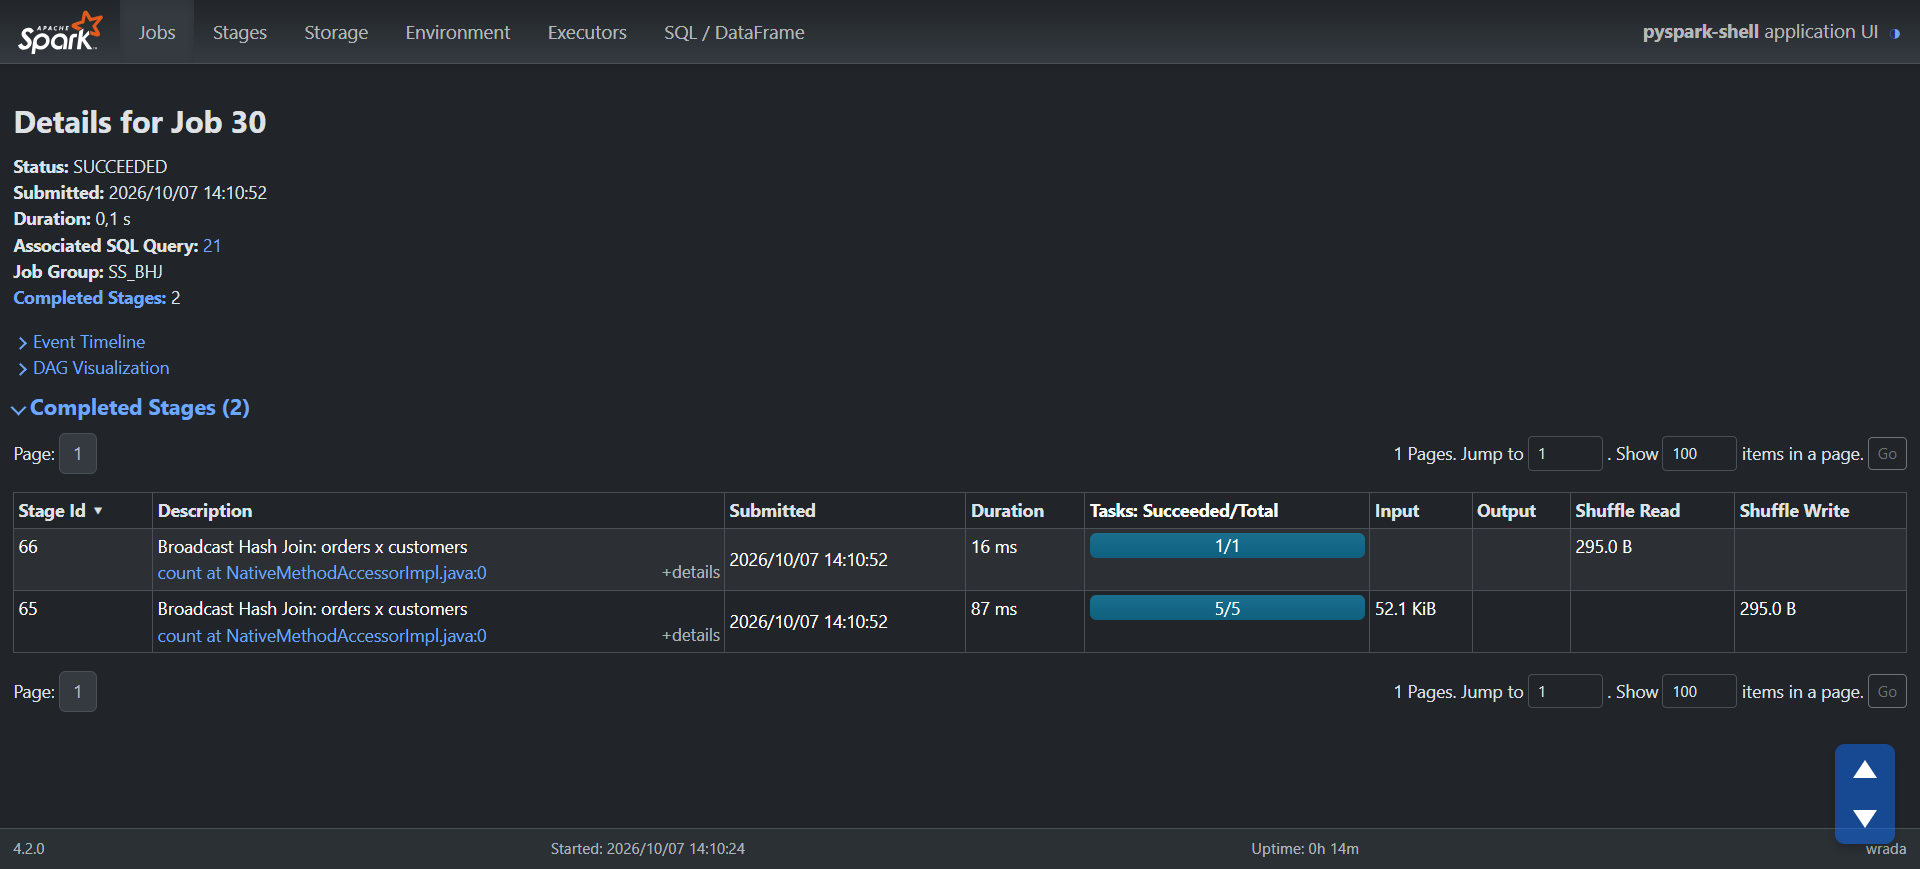

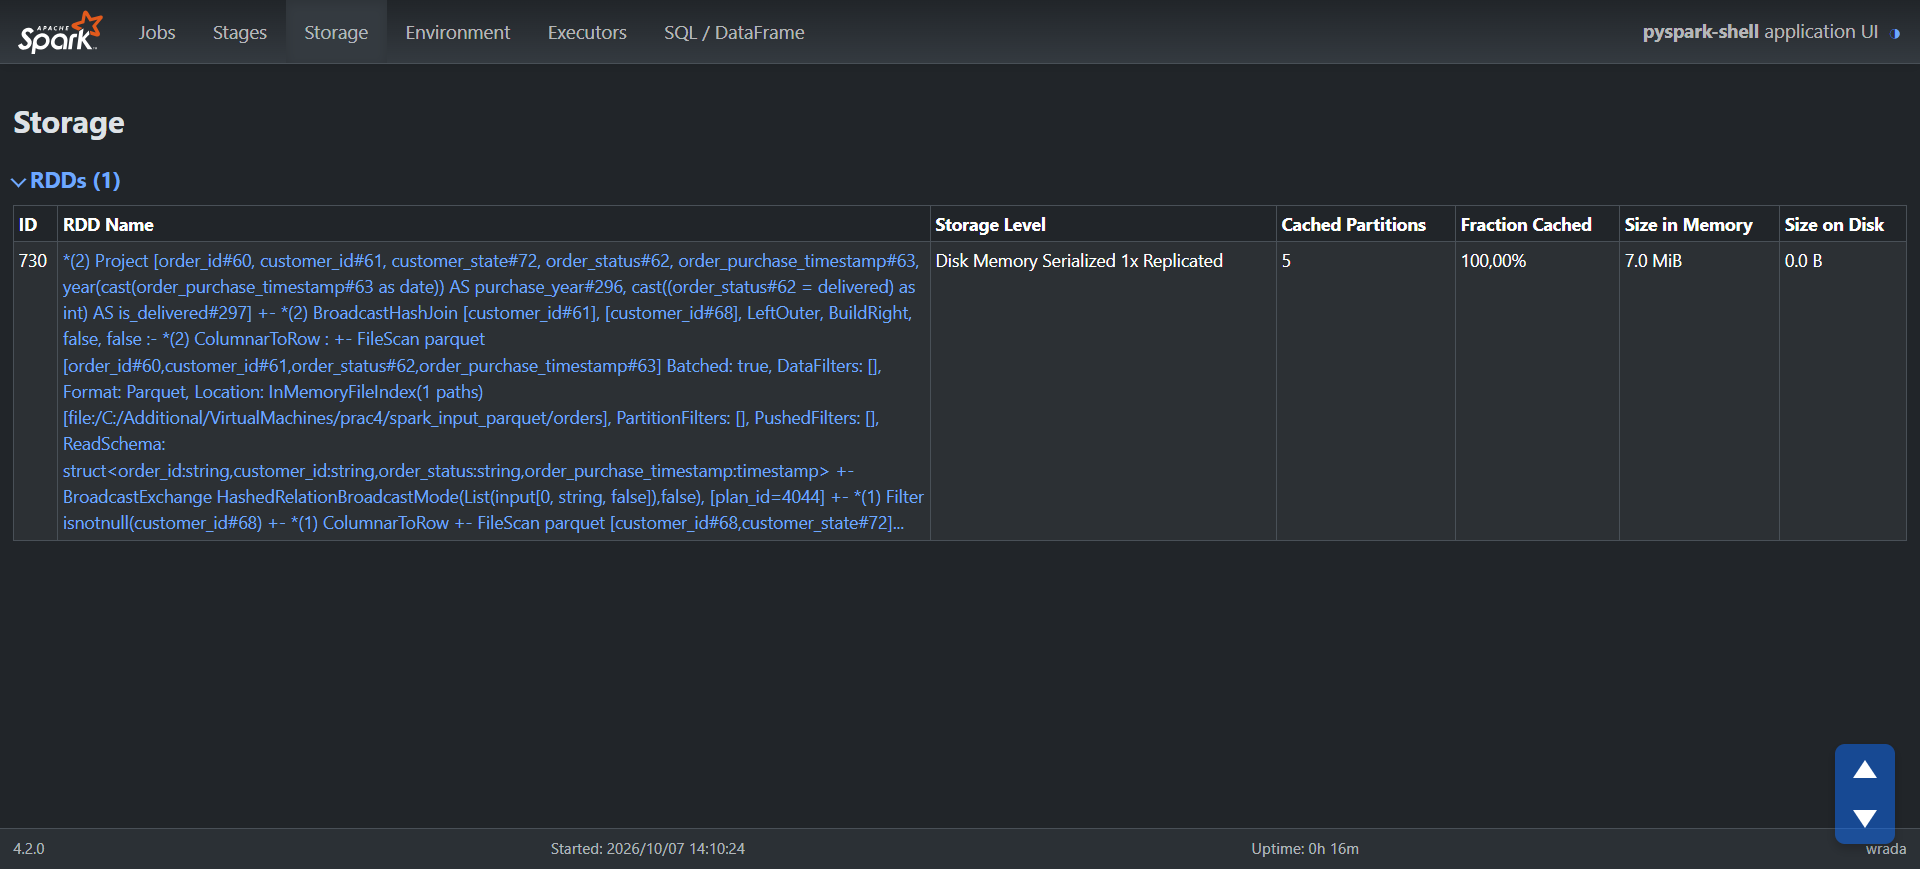


## 10. Сформулировать не менее пяти собственных экспериментальных выводов и минимум два ограничения измерений.

### Вывод 1. Lazy evaluation подтверждён на цепочке из четырёх трансформаций

**Контекст:** `orders` (99 441 строка, 5 партиций Parquet), `spark.sql.shuffle.partitions=8`, `AQE=false`, `local[*]`.
**Что делали:** построили `orders_prepared = orders.select(...).filter(...).withColumn(...).withColumn(...)` (ячейка 8), затем вызвали `count()` (ячейка 9).
**Наблюдение:** после построения DataFrame в Spark UI **не появилось новых Job** с группой `SS_LAZY`. Только `count()` инициировал Job `SS_LAZY_ACTION`. Число строк — 99 441, время — 0.566 с.
**Вывод:** Spark не выполняет вычислений без Action — строится только логический план. Замер времени вокруг цепочки transformations без Action измерял бы работу драйвера, а не обработку.

### Вывод 2. repartition() и coalesce() дают одинаковое число партиций, но разное распределение

**Контекст:** `skewed = orders.repartition(16, "order_status")`, затем `repart4 = skewed.repartition(4)`, `coal4 = skewed.coalesce(4)`.
**Что делали:** сравнили физические планы и профили партиций (ячейки 12–15).
**Наблюдение:**
- В плане `repart4` — `Exchange RoundRobinPartitioning(4)` (полное перемешивание).
- В плане `coal4` — `Coalesce 4` поверх старого `Exchange hashpartitioning(order_status, 16)` (без нового shuffle).
- Профиль `repart4`: 24 860 / 24 862 / 24 859 / 24 860 (разница max-min = **3 строки**).
- Профиль `coal4`: 615 / 1 721 / **96 480** / 625 (разница max-min = **95 865 строк**, max/min = **157×**).
**Вывод:** Одинаковое число выходных партиций (4) не означает одинаковое распределение. `repartition` даёт балансировку ценой shuffle; `coalesce` дешевле, но наследует перекос исходного разбиения. При группировке по «тяжёлому» ключу (`order_status` с доминирующим значением `delivered`) `coalesce` концентрирует 97 % данных в одной партиции.

### Вывод 3. Один groupBy порождает два Exchange, если применить orderBy к результату

**Контекст:** `customers.groupBy("customer_state").agg(count).orderBy(desc("customers"))`.
**Что делали:** `state_stats.explain("formatted")` (ячейка 19).
**Наблюдение:** в плане — **два** Exchange:
1. `hashpartitioning(customer_state, 8)` — от `groupBy`.
2. `rangepartitioning(customers DESC, 8)` — от `orderBy`.
Между ними — две фазы `HashAggregate` (partial + final). В Spark UI Job `SS_TASK4` содержит **3 стадии**.
**Вывод:** Каждое wide-преобразование добавляет Exchange и границу стадии. `orderBy` — не «бесплатная» операция после агрегации: она требует полного перемешивания ради глобального порядка. Если сортировка результата не нужна — её стоит убрать, чтобы сэкономить стадию и shuffle.

### Вывод 4. Sort Merge Join и Broadcast Hash Join на сопоставимых таблицах дают близкое время

**Контекст:** `orders` (99 441 строка, 5 партиций) ⨝ `customers` (99 441 строка, 3 партиции) по `customer_id`.
**Что делали:** SMJ (`hint("merge")`) и BHJ (`F.broadcast(customers)`) на одной сессии (ячейки 24–27).
**Наблюдение:**
- Оба варианта дали **99 441** строку — логическая эквивалентность.
- SMJ: медиана 0.650 с; план с двумя `Exchange hashpartitioning + Sort`.
- BHJ: медиана 0.565 с; план с `BroadcastExchange` и без Exchange у `orders`.
- Отношение **BHJ / SMJ = 0.87** — выигрыш BHJ около 13 %.
**Вывод:** При сопоставимых размерах сторон BHJ даёт **умеренное**, а не драматическое ускорение. Это объясняется тем, что `customers` содержит ~99k строк и ~7 MiB — объём передачи broadcast сопоставим с объёмом shuffle при SMJ. «Broadcast всегда быстрее» — миф: он выгоден, когда одна сторона существенно меньше другой. Column pruning (`customers.select("customer_id", "customer_state")`) перед broadcast дополнительно сократил бы передачу.

### Вывод 5. Зависимость времени от числа входных partitions немонотонна

**Контекст:** `spark.range(0, 5_000_000, numPartitions=p)`, `groupBy(key).agg(sum)`, `shuffle.partitions=8` (ячейка 36).
**Что делали:** p ∈ {1, 2, 4, 8, 16, 32}, по 3 замера, медиана.
**Наблюдение:** T(1) = 0.303 с — минимум. Медианы: 0.513 / 0.353 / 0.383 / 0.811 / 1.504. S(p) = T(1)/T(p) колеблется: 0.59 / 0.86 / 0.79 / 0.37 / 0.20. Локальный пик — на **p = 4** (S = 0.86), устойчивый спад при p ≥ 8.
**Вывод:** Классического U-образного ускорения нет: задача слишком лёгкая для 12-ядерного стенда. Накладные расходы планировщика и JVM-прогрева доминируют над полезной работой. Локальный пик на p = 4 согласуется с числом физических ядер — при небольшом p балансировка чуть лучше. Это подтверждает тезис методички: оптимум p существует, но зависит от масштаба задачи и сложности вычислений.

### Вывод 6. Число part-файлов прямо следует из числа partitions при записи

**Контекст:** `state_stats` (27 строк, клиенты по штатам) записан с `repartition(1)` и `repartition(4)`.
**Что делали:** записали Parquet и посчитали part-файлы и их размеры (ячейки 41–42).
**Наблюдение:** p = 1 → 1 файл, 1.0 KiB средний. p = 4 → 4 файла, 0.8 KiB средний. Общий размер вырос с 0.001 MiB до 0.003 MiB — за счёт метаданных Parquet (footer) на каждый файл.
**Вывод:** Одна задача записи = один part-файл. При больших наборах это становится проблемой small files: тысячи мелких файлов увеличивают стоимость операций `list`, `open` и планирования задач. Оптимум числа partitions при записи определяется будущим сценарием чтения, а не «универсальным правилом».

---

### Ограничение 1. Все замеры — на одном локальном стенде

Windows 11, 12 логических CPU, 15.7 GiB RAM, `local[*]`, PySpark 4.2, Java 17. Модель «partition → task» сохраняется, но **сетевого shuffle нет** — обмен идёт через локальный диск и память. Абсолютные времена несопоставимы с кластером. Выводы о физических планах верны именно для зафиксированной конфигурации; на реальном кластере они могут отличаться (AQE, размеры данных, наличие сети).

### Ограничение 2. Высокая дисперсия на лёгких задачах

В бенчмарке разброс трёх замеров достигает 2–3 раз (например, p = 2: 0.871 / 0.324 / 0.513). Причины — JVM-прогрев, JIT-компиляция, файловый кэш ОС, фоновая нагрузка. Медиана сглаживает, но не убирает шум. Для устойчивых выводов нужны 5–7 повторов и/или более тяжёлая вычислительная нагрузка на строку.

### Ограничение 3. Искусственные условия эксперимента

`AQE=false` и `autoBroadcastJoinThreshold=-1` отключены специально для управляемости. В реальном Spark 4.2 AQE включён по умолчанию и может на лету менять число shuffle-партиций, объединять мелкие партиции и выбирать другую JOIN-стратегию на основе runtime-статистики. Кроме того, размеры `state_stats` (27 строк) и итоговых файлов (единицы KiB) слишком малы, чтобы напрямую переносить выводы о small files на реальные большие данные.

In [24]:
spark.catalog.clearCache()
spark.stop()